# San Diego Analysis
Example workbook to show how to analyze historical NOAA data for San Diego

In [25]:
import os
from datetime import datetime

import matplotlib.pyplot as plt
import noaa

TOKEN = "<your-token-here>"

## Find San Diego Location ID

First, let's find the San Diego location by iterating over the locations until we find San Diego.

In [2]:
# NOAA max limit is 1000
with noaa.Client(token=TOKEN) as client:
    locations = client.get_locations(location_category_id="CITY", limit=1000)

san_diego_loc = None
for loc in locations.results:
    if "san diego" in loc.name.lower():
        san_diego_loc = loc

print(san_diego_loc)

None


Not in the first batch, so let's offset it and look at the second.

In [3]:
with noaa.Client(token=TOKEN) as client:
    locations = client.get_locations(location_category_id="CITY", limit=1000, offset=1000)

san_diego_loc = None
for loc in locations.results:
    if "san diego" in loc.name.lower():
        san_diego_loc = loc

print(san_diego_loc)

min_date='1850-10-01' max_date='2026-09-17' name='San Diego, CA US' data_coverage=1.0 id='CITY:US060030'


Found it - looks like the location id is `CITY:US060030`.

## Find available data

Now that we have the location - we can find the available datasets and data types for it.

In [4]:
with noaa.Client(token=TOKEN) as client:
    datasets = client.get_datasets(location_id=san_diego_loc.id)

for ds in datasets.results:
    print(f"{ds.id} - {ds.name} - {ds.min_date} - {ds.max_date}")

GHCND - Daily Summaries - 1763-01-01 - 2026-09-14
GSOM - Global Summary of the Month - 1763-01-01 - 2026-09-01
GSOY - Global Summary of the Year - 1763-01-01 - 2026-01-01
NEXRAD2 - Weather Radar (Level II) - 1991-06-05 - 2026-09-17
NEXRAD3 - Weather Radar (Level III) - 1994-05-20 - 2026-09-16
NORMAL_ANN - Normals Annual/Seasonal - 2010-01-01 - 2010-01-01
NORMAL_DLY - Normals Daily - 2010-01-01 - 2010-12-31
NORMAL_HLY - Normals Hourly - 2010-01-01 - 2010-12-31
NORMAL_MLY - Normals Monthly - 2010-01-01 - 2010-12-01
PRECIP_15 - Precipitation 15 Minute - 1970-05-12 - 2014-01-01
PRECIP_HLY - Precipitation Hourly - 1900-01-01 - 2014-01-01


A bit of a bummer that a lot of these datasets are no longer up to date. Let's look at the Daily Summaries `GHCND`.

In [5]:
with noaa.Client(token=TOKEN) as client:
    data_types = client.get_data_types(dataset_id="GHCND", location_id=san_diego_loc.id, limit=100)

for dt in data_types.results:
    print(f"{dt.id} - {dt.name} - {dt.min_date} - {dt.max_date}")


ACMH - Average cloudiness midnight to midnight from manual observations - 1965-01-01 - 2005-12-31
ACSH - Average cloudiness sunrise to sunset from manual observations - 1965-01-01 - 2005-12-31
AWND - Average wind speed - 1982-01-01 - 2026-09-13
DAEV - Number of days included in the multiday evaporation total (MDEV) - 1934-02-03 - 2012-07-23
DAPR - Number of days included in the multiday precipitation total (MDPR) - 1832-05-11 - 2026-09-14
DASF - Number of days included in the multiday snow fall total (MDSF)  - 1844-02-24 - 2026-02-23
DAWM - Number of days included in the multiday wind movement (MDWM) - 1935-09-23 - 2010-06-21
EVAP - Evaporation of water from evaporation pan - 1893-01-09 - 2026-08-31
FMTM - Time of fastest mile or fastest 1-minute wind - 1982-01-01 - 2013-03-31
MDEV - Multiday evaporation total (use with DAEV) - 1934-02-03 - 2010-08-16
MDPR - Multiday precipitation total (use with DAPR and DWPR, if available) - 1832-05-11 - 2026-09-14
MDSF - Multiday snowfall total  - 1

"Blowing of drifting snow" is such an interesting data type - though doesn't make much sense for San Diego. For funsies, let's look at that, average temperature, and precipitation.

## Get Data

Let's get data for these data types - `WT09`, `TAVG`, and `PRCP` for 2026-09-01 to 2026-09-14.

In [6]:
with noaa.Client(token=TOKEN) as client:
    data = client.get_data(
        dataset_id="GHCND",
        location_id=san_diego_loc.id,
        data_type_id=",".join(["WT09", "TAVG", "PRCP"]),
        start_date="2026-09-01",
        end_date="2026-09-14",
        limit=1000,
    )

In [7]:
data_prcp = []
data_wt09 = []
data_tavg = []
for d in data.results:
    if d.data_type == "PRCP":
        data_prcp.append((d.date, d.value))
    elif d.data_type == "WT09":
        data_wt09.append((d.date, d.value))
    elif d.data_type == "TAVG":
        data_tavg.append((d.date, d.value))

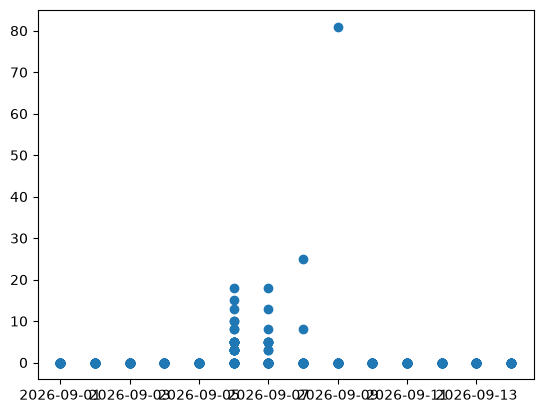

In [17]:
plt.plot(
    [datetime.strptime(d[0], "%Y-%m-%dT00:00:00") for d in data_prcp],
    [d[1] for d in data_prcp],
    "o",
)

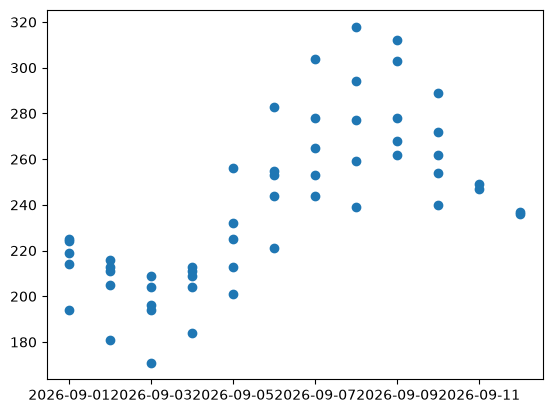

In [18]:
plt.plot(
    [datetime.strptime(d[0], "%Y-%m-%dT00:00:00") for d in data_tavg],
    [d[1] for d in data_tavg],
    "o",
)

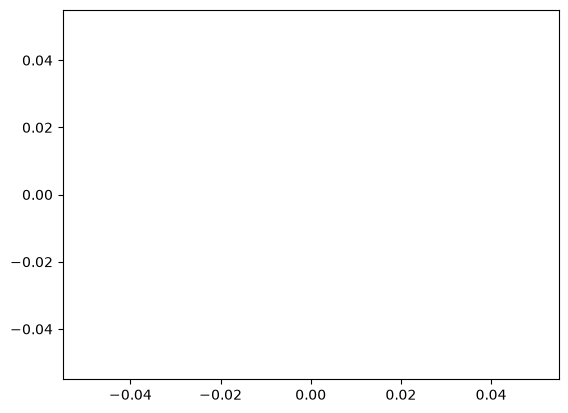

In [19]:
plt.plot(
    [datetime.strptime(d[0], "%Y-%m-%dT00:00:00") for d in data_wt09],
    [d[1] for d in data_wt09],
    "o",
)